# Variable Selection and First Nowcast

This notebook escalates in complexity.

This activity will use python to perform variable selection in a dataset and estimate a simple Nowcasting model based on OLS. We will:

- Load a full data
- Estimate LARS and compare it with OLS
- Nowcast GDP with OLS and several information sets

*Make sure the data folder is in the same directory as this notebook.*

This Notebook has **parts** of the code you need to to the tasks above. Follow the notes to complete or write the pieces of code you may need to finish.



## Load Libraries

First, we load and verify that libraries load correctly. Otherwise, install via conda or pip

You may have to install any of the following:

```conda install scikit-learn --yes```

```conda install matplotlib --yes```

```conda install statsmodels --yes```

In [1]:
import pandas as pd                          # pandas: the main library for tabular data (DataFrames)
import numpy as np                           # numpy: fast math and array operations
import matplotlib.pyplot as plt              # pyplot: plotting library (like ggplot in R)

from sklearn.linear_model import LinearRegression   # OLS regression from scikit-learn
from statsmodels.tsa.seasonal import seasonal_decompose  # decompose a series into trend + seasonal + residual

from sklearn.decomposition import PCA               # Principal Component Analysis
from sklearn.preprocessing import StandardScaler    # standardize features to mean=0, std=1
from sklearn.metrics import mean_squared_error      # computes MSE between predictions and actuals
from sklearn.model_selection import train_test_split  # utility to split data into train/test sets

from copy import deepcopy                    # deepcopy creates a fully independent copy of an object
from sklearn.linear_model import Lars        # LARS: Least Angle Regression for variable selection

scaler = StandardScaler()                    # create a scaler object (will be used later to standardize data)

target_variable = "RGDP0000"                # string: the column name for Barbados real GDP (our Y variable)

# Load the data

We are first going to define the extend of our training/test samples

In [2]:
# ---------------------------------------------------------
# 1) DEFINE TRAIN / TEST WINDOW
# ---------------------------------------------------------
# These dates define the sample splits used for model training and evaluation.
# - Training sample:   [train_start_date, test_start_date)
# - Test sample:       [test_start_date, test_end_date]
train_start_date = "2015-03-01"   # strings in ISO format: "YYYY-MM-DD"
test_start_date  = "2023-06-01"

# pd.to_datetime() converts a string into a pandas Timestamp (a proper date object)
train_start_date = pd.to_datetime(train_start_date)
test_start_date  = pd.to_datetime(test_start_date)

# ---------------------------------------------------------
# 2) DEFINE OUT-OF-SAMPLE FORECAST TARGET (LAST DATE / VINTAGE)
# ---------------------------------------------------------
# This is the date for which you want to produce the final nowcast/forecast.
# Use the first day of the month (or the appropriate GDP reference month).
desired_date = pd.to_datetime("2026-03-01")


Read and clean (seasonality and stationarity) the data.

In [3]:
# pd.read_csv() loads a CSV file into a DataFrame; parse_dates=True converts date strings automatically
# index_col='date' sets the 'date' column as the row index instead of a plain column
data = pd.read_csv('../data/data.csv', parse_dates=True, index_col='date')

# .dropna() removes rows where GDP is NaN; .index.max() returns the latest date remaining
test_end_date = data[target_variable].dropna().index.max()

data.head(2)   # .head(n) shows the first n rows â€” useful for a quick sanity check

,RGDP0000,RGDP0003,RGDP0004,RGDP0005,RGDP0006,RGDP0007,RGDP0008,RGDP0009,RGDP0010,RGDP0011,...,UNTL3106,UNTL3107,UNTL3108,UNTL3113,UNTL3109,UNTL3110,UNTL3111,UNTL3112,UNTL0000,UNTL0001
date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**COMPLEX SEASONALITY AND GROWTH RATES**

Our dataset has mixed frequencies. This time we will start accounting for mixed frequencies.

We are going to apply seasonality filters based on the data frequency. To do so, load the ```metadata.csv``` --a file that describes all variables in the data.

In [4]:
metadata = pd.read_csv('../data/meta.csv')   # load the metadata CSV as a separate DataFrame
# The column with variable names
meta_col = 'ticket'   # 'ticket' is the column in metadata that holds the variable name/code

metadata   # displaying a variable on the last line of a cell prints it in the notebook output

,series,ticket,description,description 2,freq,first_date,last_date,No Obs,months_lag,nominal,sa,unstructured,type,agg_method,file_name,first_obs,last_obs
0,NearNadir_Composite_Snow_Free,UMBL0000,NearNadir_Composite_Snow_Free,NaN,monthly,2025-11-01,2026-02-01,4,3.0,0,0,1,NaN,sum,blk_ntl.csv,2025-11-01,2026-02-01
1,USA_exp_BRB,TEXP0004,USA_exp_BRB,NaN,monthly,1992-01-01,2026-03-01,195,2.0,0,0,0,NaN,mean,uscensus_trade.csv,1992-01-01,2026-03-01
2,USA_imp_BRB,TIMP0004,USA_imp_BRB,NaN,monthly,1992-01-01,2026-03-01,195,2.0,0,0,0,NaN,mean,uscensus_trade.csv,1992-01-01,2026-03-01
3,bank_rate_barbados,FDEP0015,bank_rate_barbados,NaN,monthly,1990-01-01,2026-03-01,195,2.0,0,0,0,NaN,mean,cbbb_interest.csv,1990-01-01,2026-03-01
4,bank_rate_canada,FDEP0023,bank_rate_canada,NaN,monthly,1990-01-01,2026-03-01,195,2.0,0,0,0,NaN,mean,cbbb_interest.csv,1990-01-01,2026-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,treasury_bill_rate_uk,FDEP0024,treasury_bill_rate_uk,NaN,monthly,1990-01-01,2026-03-01,190,2.0,0,0,0,NaN,mean,cbbb_interest.csv,1990-01-01,2026-03-01
454,treasury_bill_rate_usa,FDEP0026,treasury_bill_rate_usa,NaN,monthly,1990-01-01,2026-03-01,195,2.0,0,0,0,NaN,mean,cbbb_interest.csv,1990-01-01,2026-03-01
455,unemployed,RUNE0000,unemployed,NaN,monthly,NaN,NaN,0,NaN,0,0,0,NaN,mean,NaN,NaN,NaN
456,unemployed_female,RUNE0002,unemployed_female,NaN,monthly,NaN,NaN,0,NaN,0,0,0,NaN,mean,NaN,NaN,NaN


The metadata describes which variables are real vs nominal. Use this information to deflate.

In [5]:
cpi = 'MCPI0000'   # string variable holding the CPI column name
# =========================================================
# Deflate nominal variables using CPI (base year: 2019 average, BSSJA 2019=100)
# =========================================================
# Many series are nominal; deflating them puts everything in real terms.
# We compute a CPI base as the average CPI level in 2019 (BSSJA 2019=100 â†’ base = 100).
base = data[cpi][data.index.year == 2019].mean()   # beta11: base year 2019 (Barbados official)
# data.index.year == 2019 is a boolean mask; it selects only rows where the year is 2019

# metadata.loc[condition][column].values extracts matching column values as a numpy array
nominal = metadata.loc[metadata["nominal"] == 1][meta_col].values

# Deflate: Real_t = Nominal_t / CPI_t * CPI_base   (corrected: was multiplying)
for column in data.columns:       # loop over every column name in the DataFrame
    if column in nominal:         # 'in' checks whether a value exists in a list/array
        data[column] = data[column] / data[cpi] * base    # beta11: divide (deflate) not multiply

# .drop() removes columns (axis=1) or rows (axis=0); inplace=True modifies the DataFrame directly
data.drop(columns=[cpi], inplace=True)
# Drop GDP components
# Drop those columns
data = data.drop(columns=[col for col in data.columns if 'RGDP' in col and col != 'RGDP0000'])
# list comprehension: builds a list of column names where 'RGDP' appears but keeping the target

Here we address seasonality with different filters depending on whether data is monthly, weekly, daily, or quarterly.

In [6]:
# .str accessor lets you use string methods on a Series; .str.lower() converts to lowercase
quarterly  = metadata.loc[metadata["freq"].str.lower().str.contains("q")][meta_col].values
monthly    = metadata.loc[metadata["freq"].str.lower().str.contains("m")][meta_col].values
already_sa = metadata.loc[metadata["sa"]==1][meta_col].values   # sa=1 means already seasonally adjusted

# Keep only columns with at least 24 non-NaN values; .notna().sum() counts non-missing entries per column
data = data.loc[:, data.notna().sum() >= 24]

for column in data.columns:
    if column in already_sa:
        continue   # 'continue' skips the rest of the loop body and moves to the next column
    series = data[column].dropna()   # remove NaN before decomposing (seasonal_decompose requires it)
    if column in quarterly:
        # period=4: quarterly series has 4 seasons per year
        decomp = seasonal_decompose(series, model='additive', extrapolate_trend='freq', period=4)
        data[column] = data[column] - decomp.seasonal   # subtract seasonal component to remove seasonality
    else :
        # period=12: monthly series has 12 seasons per year
        decomp = seasonal_decompose(series, model='additive', extrapolate_trend='freq', period=12)
        data[column] = data[column] - decomp.seasonal


Now calculate growth rates:

In [7]:
# =========================================================
# Convert levels to growth rates (percent change)
# =========================================================
# Quarterly series: quarter-over-quarter growth rate
# All other series: default percent change at their observed frequency
for column in data.columns:
    if column in quarterly:
        # Get non-NaN values with their original index
        non_nan = data[column].dropna()
        
        # .pct_change(periods=1) computes (x_t - x_{t-1}) / x_{t-1}; * 100 gives percentage
        pct_change_values = non_nan.pct_change(periods=1, fill_method=None) * 100
        
        # Create a full-length Series of NaN, then fill in only the computed positions
        result = pd.Series(np.nan, index=data.index)
        result.loc[pct_change_values.index] = pct_change_values   # .loc with an index selects by label
        
        data[column] = result
    else:
        # Store original NaN mask
        original_was_nan = data[column].isna()   # boolean Series: True where value is missing
        
        # For monthly/weekly/daily, calculate normally
        pct_change_values = data[column].pct_change(periods=1, fill_method=None) * 100
        
        # Mask out cases where either current or previous value was originally NaN
        prev_was_nan = data[column].shift(1).isna()   # .shift(1) shifts values down by 1 row
        pct_change_values[prev_was_nan | original_was_nan] = np.nan   # | is the bitwise OR for booleans

        data[column] = pct_change_values

# np.inf arises from pct_change when dividing by zero; replace with NaN to keep data clean
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================================================
# Drop columns in quarterly with more than 75% missing values
# =========================================================
for column in [ col for col in data.columns if col not in quarterly ] :
    # compute fraction of missing values in the training period only
    missing_pct = data[data.index<=test_start_date][column].isna().sum() / len(data[data.index<=test_start_date][column])
    if missing_pct > 0.75:
        data.drop(column, axis=1, inplace=True)

# =========================================================
# Final cleaning
# =========================================================
# Replace infinities created by pct_change with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop CPI from predictor set (used only for deflation)
#data.drop(cpi, axis=1, inplace=True)

# ~ negates a boolean Series; data[condition] filters rows where condition is True
data = data[~(data.index < train_start_date)].reset_index(drop=False)
# .reset_index(drop=False) moves the date index back to a regular column
data = data.set_index("date").dropna(how="all", axis=0)   # drop rows that are entirely NaN

# pd.to_numeric(..., errors='coerce') converts to number; non-numeric values become NaN
metadata["months_lag"] = (
    pd.to_numeric(metadata["months_lag"], errors="coerce")
      .fillna(1)      # replace any NaN lags with 1 (safe default)
      .astype(int)    # .astype(int) casts the Series to integer dtype
)

# Drop those columns
data = data.drop(columns=[col for col in data.columns if 'RGDP' in col and col != 'RGDP0000'])
for col in data.columns :
    last = data[col].dropna().index.max().year   # find the most recent year with data for this column
    if last < 2024 :
        data.drop(col, axis=1, inplace=True)   # remove columns that stopped updating before 2024

Remove highly correlated predictors before LARS. Sub-components of the same category (e.g. BOP financial-account sub-accounts) are nearly collinear â€” LARS picks several without adding information. For each correlated pair the function keeps whichever variable is an aggregate (ticket number ends in `00`); otherwise it keeps the one with more non-null observations.

In [8]:
def deduplicate_correlated(df, threshold=0.85, target=target_variable,
                           metadata=metadata, meta_col=meta_col):
    """Drop one variable from each highly-correlated pair.
    Priority: (1) keep aggregate tickets (numeric suffix % 100 == 0);
              (2) keep the variable with more non-null observations.
    """
    import re

    def _is_agg(ticket):
        nums = re.findall(r'\d+', str(ticket))
        return bool(nums) and int(nums[-1]) % 100 == 0

    agg_set = set(metadata.loc[metadata[meta_col].apply(_is_agg), meta_col])

    X   = df.drop(columns=[target])
    obs = X.notna().sum()
    corr  = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = set()
    for col in upper.columns:
        if col in to_drop:
            continue
        peers = upper.index[upper[col] > threshold].tolist()
        for peer in peers:
            if peer in to_drop:
                continue
            col_agg  = col  in agg_set
            peer_agg = peer in agg_set
            if col_agg and not peer_agg:
                to_drop.add(peer)
            elif peer_agg and not col_agg:
                to_drop.add(col)
                break
            elif obs[col] >= obs[peer]:
                to_drop.add(peer)
            else:
                to_drop.add(col)
                break

    kept = [c for c in df.columns if c not in to_drop]
    print(f"Removed {len(df.columns) - len(kept)} correlated variables "
          f"(|r| > {threshold}). {len(kept)} remain.")
    return df[kept]

data = deduplicate_correlated(data, threshold=0.98)

# Drop high-publication lag series
tickets_to_keep = metadata[metadata.months_lag <= 5]['ticket'].tolist()

# Keep only these columns (that exist in data)
data = data[[ col for col in data.columns if col in tickets_to_keep or "RGDP" in col ]]


Removed 49 correlated variables (|r| > 0.98). 360 remain.


Glimpse at the data

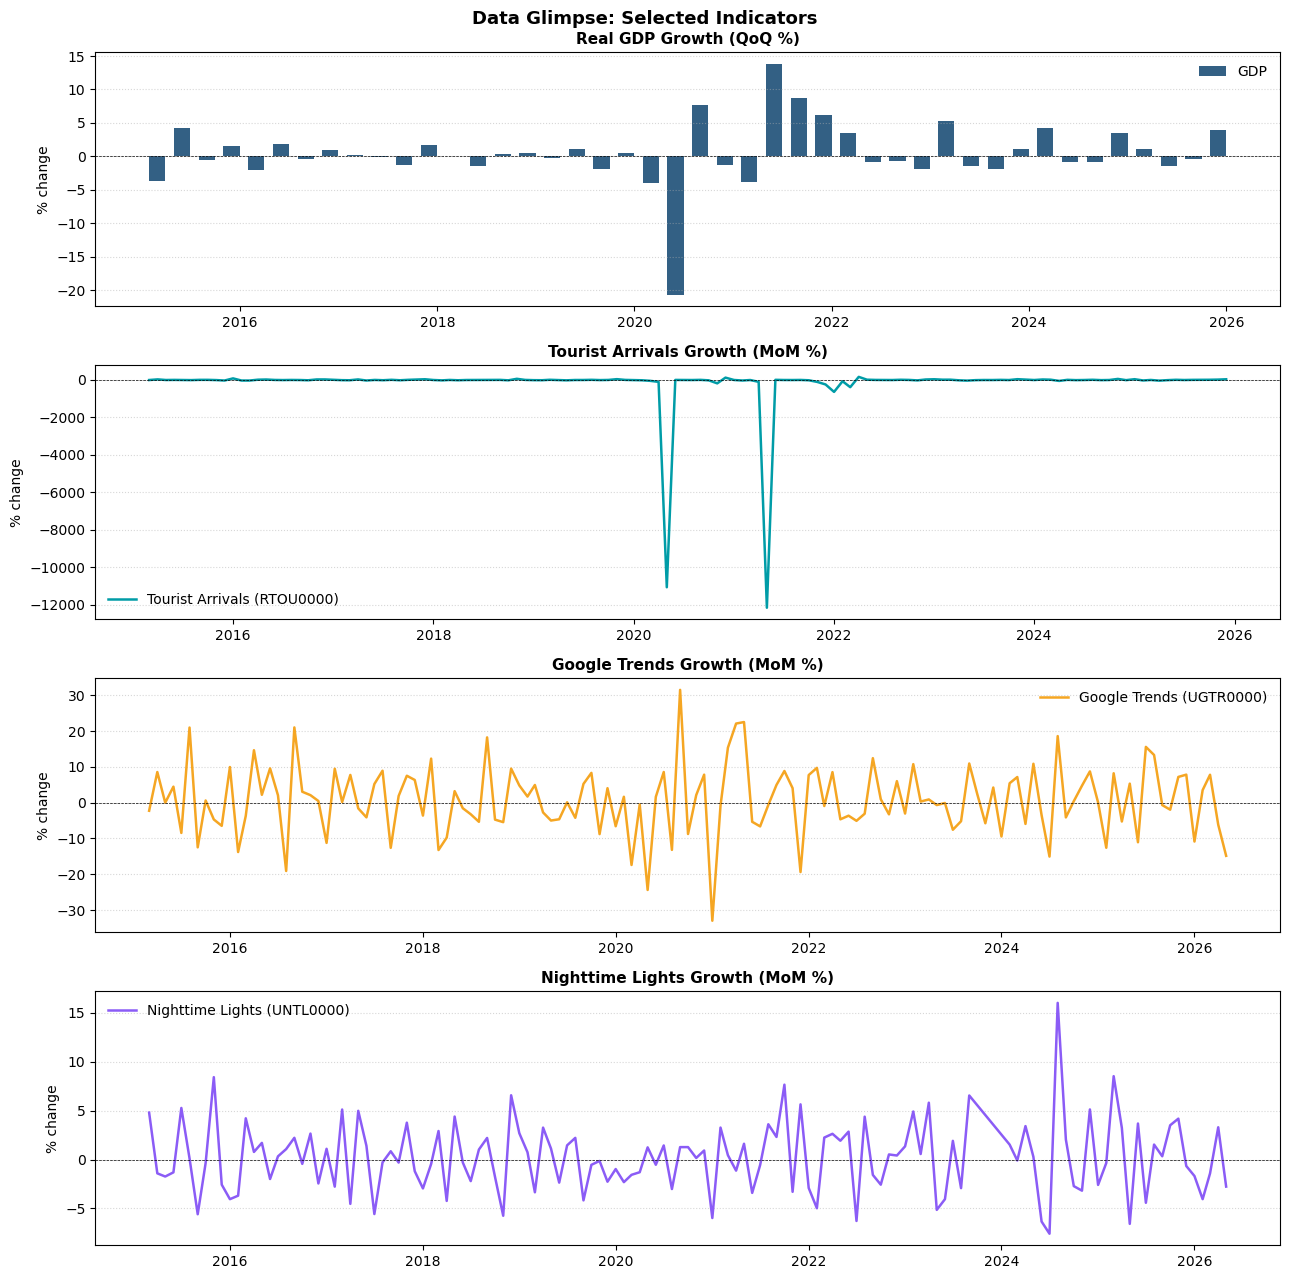

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=False)

# GDP (quarterly) bar chart
ax = axes[0]
gdp = data['RGDP0000'].dropna()
ax.bar(gdp.index, gdp, width=60, color='#003865', alpha=0.8, label='GDP')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Real GDP Growth (QoQ %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Tourist Arrivals (RTOU0000)
ax = axes[1]
pay = data['RTOU0000'].dropna()
ax.plot(pay.index, pay, color='#009CA7', linewidth=1.8, label='Tourist Arrivals (RTOU0000)')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Tourist Arrivals Growth (MoM %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Google Trends (UGTR0000)
ax = axes[2]
gtr = data['UGTR0000'].dropna()
ax.plot(gtr.index, gtr, color='#F5A623', linewidth=1.8, label='Google Trends (UGTR0000)')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Google Trends Growth (MoM %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Nighttime Lights (UNTL0000)
ax = axes[3]
ntl = data['UNTL0000'].dropna()
ax.plot(ntl.index, ntl, color='#8B5CF6', linewidth=1.8, label='Nighttime Lights (UNTL0000)')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Nighttime Lights Growth (MoM %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle('Data Glimpse: Selected Indicators', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

In [10]:
# =========================================================
# Reproducibility: print core library versions
# =========================================================
print("================== Library Versions =================")
import sklearn, numpy, pandas
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)


# Data dimensions (observations and variables)
print("Data dimensions:", data.shape)
print(f"Training dates: {train_start_date.strftime('%Y-%m-%d')} to {(test_start_date - pd.DateOffset(days=1)).strftime('%Y-%m-%d')}")
T1 = data[data.index < test_start_date].shape[0]
T2 = data[(data.index >= test_start_date) & (data.index <= test_end_date)].shape[0]
print(f"Training periods: {T1} ({T1/(T1+T2) :.2%})")
print(f"Testing dates: {test_start_date.strftime('%Y-%m-%d')} to {test_end_date.strftime('%Y-%m-%d')}")
print(f"Testing periods: {T2} ({T2/(T1+T2) :.2%})")

================== Library Versions =================
scikit-learn: 1.8.0
numpy: 2.4.1
pandas: 2.3.3
Data dimensions: (135, 322)
Training dates: 2015-03-01 to 2023-05-31
Training periods: 99 (76.15%)
Testing dates: 2023-06-01 to 2025-12-01
Testing periods: 31 (23.85%)


# Variable Selection: LARS

Start by loading the helper functions.

In [11]:
def estimate_factors(X, r_max=10, criterion='IC1'):
    '''
    Information criteria to PCA.
    Bai and Ng (2002)
    inputs:
    - X: df
    - r_max: max number of factors (should be less than T or N)
    - criterion: conservative criteria is IC3
    '''
    
    T, N = X.shape
    r_max = min(r_max, T - 1)  # enforce theoretical max
    IC_vals = []
    
    for r in range(r_max + 1):
        if r == 0:
            sigma2_r = np.mean(X.values ** 2)
        else:
            pca = PCA(n_components=r)
            X_scaled = scaler.fit_transform(X)
            F_hat = pca.fit_transform(X_scaled)
            Lambda_hat = X_scaled.T @ F_hat / T
            X_hat = F_hat @ Lambda_hat.T
            sigma2_r = np.mean((X_scaled - X_hat).values ** 2)
    
        if criterion == 'IC1':
            penalty = r * (N + T) / (N * T) * np.log(N * T / (N + T))
        elif criterion == 'IC2':
            penalty = r * (N + T) / (N * T) * np.log(min(N, T))
        elif criterion == 'IC3':
            penalty = r * np.log(min(N, T)) / min(N, T)
        else:
            raise ValueError("Invalid criterion")
    
        IC_vals.append(np.log(sigma2_r) + penalty)

    return np.argmin(IC_vals)



def lars_variable_ranking(df, target, max_vars=None, test=None, factors=5):
    """
    Stepwise LARS variable selection: rank variables by their entry into the model.
    - df: DataFrame with predictors and target (train period only)
    - target: name of the target variable
    - max_vars: number of variables to select; if None, continue until all are ranked
    - test: DataFrame with test period rows (same columns as df)
    Returns:
    - selected_vars: ordered list of variable names by entry into the LARS model
    - rmse: out-of-sample RMSE on the test period (or None)

    Chinn, M. D., Meunier, B., & Stumpner, S. (2023). Nowcasting world trade with machine learning: a three-step approach (No. w31419). National Bureau of Economic Research.
    """
    df0 = deepcopy(df)
    
    selected_order = []
    count = 0
    max_vars = max_vars or (df0.shape[1] - 1)

    while count < max_vars:
        X = df0.drop(columns=[target])
        y = df0[target]

        # Stop if no variables remain
        if X.shape[1] == 0:
            break

        # Fit LARS model (drop NaN rows for fitting)
        mask = y.notna()
        model = Lars(n_nonzero_coefs=X.shape[1], jitter=1e-10, random_state=0)
        model.fit(X[mask], y[mask])

        # coef_path_ has shape (n_features, n_steps)
        coef_path = np.array(model.coef_path_)
        # Count how many times each variable is zero
        zero_counts = (coef_path == 0).sum(axis=1)

        # Summary table
        out = pd.DataFrame({'Variable': X.columns, 'ZeroCount': zero_counts})
        out = out.sort_values('ZeroCount')
        
        # Take variables that are uniquely at this ZeroCount level
        grouped = out.groupby('ZeroCount')
        selected = grouped.filter(lambda g: len(g) == 1)

        # If nothing uniquely enters, dump all remaining vars
        if selected.empty:
            remaining = X.columns.tolist()
            selected = pd.DataFrame({'Variable': remaining, 'ZeroCount': [count]*len(remaining)})
            selected_order.extend(remaining)
            print("Warning: Using fallback procedure for LARS")
            break
        else:
            selected_vars = selected['Variable'].tolist()
            selected_order.extend(selected_vars)
            df0 = df0.drop(columns=selected_vars)
            count += len(selected_vars)

    top_vars = selected_order[:max_vars]

    if test is None:
        return top_vars, None

    # --- Evaluation: mirror the benchmark OLS setup exactly ---
    df_train = df[  [target] + top_vars]
    df_test  = test[[target] + top_vars]

    X_train_raw = df_train.drop(target, axis=1)
    X_test_raw  = df_test.drop(target, axis=1)
    y_train_all = df_train[target]
    y_test_all  = df_test[target]

    # Fit scaler on train only, transform both (no data leakage)
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_raw), index=X_train_raw.index
    ).dropna(axis=1)
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_raw), index=X_test_raw.index
    )[X_train_scaled.columns]

    # Fit PCA on train only, transform both
    pca_local = PCA(n_components=factors)
    X_train_pca = pd.DataFrame(
        pca_local.fit_transform(X_train_scaled), index=X_train_raw.index,
        columns=[f"PC_{i}" for i in range(factors)]
    )
    X_test_pca = pd.DataFrame(
        pca_local.transform(X_test_scaled), index=X_test_raw.index,
        columns=[f"PC_{i}" for i in range(factors)]
    )

    # Drop NaN GDP rows from training (same as benchmark obs_mask)
    obs_mask = y_train_all.notna()
    X_train_pca = X_train_pca[obs_mask]
    y_train_fit = y_train_all[obs_mask]

    # Drop NaN GDP rows from test when computing RMSE
    obs_mask_test = y_test_all.notna()
    X_test_eval  = X_test_pca[obs_mask_test]
    y_test_eval  = y_test_all[obs_mask_test]

    final_model = LinearRegression()
    final_model.fit(X_train_pca, y_train_fit)
    y_pred = final_model.predict(X_test_eval)

    rmse = float(np.sqrt(np.mean((y_test_eval.values - y_pred) ** 2)))
    return top_vars, rmse

Define how many factors we will use in the exercise

In [12]:
import warnings
warnings.filterwarnings('ignore')   # suppress non-critical warnings to keep output clean
factors = 1   # number of PCA factors used throughout the notebook

After the functions are prepared, we proceed by reshaping our dataset.

The data has mixed frequencies. We will aggregate data into quarterly by using the average, sum, and end-of-period values. We define in the metadata what type of aggregation to use for each variable.

In [13]:
# .set_index('ticket') makes ticket the index so we can look up agg_method by variable name
# .to_dict() converts the resulting Series into a plain Python dictionary {ticket: agg_method}
agg_map = metadata.set_index('ticket')['agg_method'].to_dict()

# Dictionary comprehension: build {col: aggregation_function} for every column in data
# If agg_method is not 'mean', 'last', or 'sum', fall back to 'mean'
agg_funcs = {
    col: (agg_map[col] if agg_map[col] in ['mean', 'last', 'sum'] else 'mean')
    for col in data.columns if col in agg_map
}
# .resample('QS') groups observations by quarter-start; .agg() applies a different function per column
pre_selected = data.resample('QS').agg(agg_funcs)
pre_selected.tail(5)   # .tail(5) shows the last 5 rows

,RGDP0000,RTOU0001,RTOU0003,RTOU0005,RTOU0000,RTOU1000,TBBI0000,TBBE0000,TBBE0001,TNET0000,...,UNTL3105,UNTL3106,UNTL3107,UNTL3108,UNTL3113,UNTL3109,UNTL3110,UNTL3111,UNTL3112,UNTL0000
date,,,,,,,,,,,,,,,,,,,,,
2025-04-01,-1.366655,-1.833080,-24.126495,-56.273260,-35.049033,-12.694205,-24.374757,-0.026169,-22.406383,-28.851739,...,-0.264528,2.126124,-1.823828,0.210751,-0.657640,-0.715800,-0.219595,0.977658,2.587271,0.112874
2025-07-01,-0.343411,1.437088,15.550339,1.735996,12.396051,-11.343636,14.337464,-4.996824,-4.433727,18.924466,...,0.948731,-3.040969,9.538586,-3.553859,-1.608871,-1.130538,0.501682,1.344523,-1.937532,-0.853253
2025-10-01,3.883935,57.656063,60.297799,118.149439,68.982053,21.133064,-7.154345,3.845400,-0.199756,-7.776015,...,1.977030,-0.085681,-1.698997,0.433314,1.008449,1.283820,1.281080,-0.534037,0.143400,2.342506
2026-01-01,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.694332,-0.696592,-5.361613,3.320450,1.442223,2.179594,-0.513199,-0.562318,0.372543,-2.386094
2026-04-01,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.713553,-1.806491,16.168368,-2.483585,1.186554,2.419050,1.155712,1.029336,-0.804468,0.265970


Some additional data management:

1. Make sure the index is a date.
2. Drop missing values (over 75% missing > then dropped)
3. Fill missing values with the mean

In [14]:
pre_selected.index = pd.to_datetime(pre_selected.index)   # ensure the index is a proper DatetimeIndex
pre_selected = pre_selected.dropna(how="all", axis=1)     # drop columns that are entirely NaN
# .isnull().mean() gives the fraction of missing values per column; keep columns with <= 75% missing
pre_selected = pre_selected.loc[:, pre_selected.isnull().mean() <= 0.75]

# Mean-fill predictors only â€” leave target_variable as NaN so we can
# identify quarters without observed GDP and drop them from training.
# List comprehension: all columns except the GDP target
predictors = [c for c in pre_selected.columns if c != target_variable]
# .fillna(mean) replaces NaN with the column mean; applied only to predictor columns
pre_selected[predictors] = pre_selected[predictors].fillna(
    pre_selected[predictors].mean(numeric_only=True)
)

pre_selected.tail(5)


,RGDP0000,RTOU0001,RTOU0003,RTOU0005,RTOU0000,RTOU1000,TBBI0000,TBBE0000,TBBE0001,TNET0000,...,UNTL3105,UNTL3106,UNTL3107,UNTL3108,UNTL3113,UNTL3109,UNTL3110,UNTL3111,UNTL3112,UNTL0000
date,,,,,,,,,,,,,,,,,,,,,
2025-04-01,-1.366655,-1.833080,-24.126495,-56.273260,-35.049033,-12.694205,-24.374757,-0.026169,-22.406383,-28.851739,...,-0.264528,2.126124,-1.823828,0.210751,-0.657640,-0.715800,-0.219595,0.977658,2.587271,0.112874
2025-07-01,-0.343411,1.437088,15.550339,1.735996,12.396051,-11.343636,14.337464,-4.996824,-4.433727,18.924466,...,0.948731,-3.040969,9.538586,-3.553859,-1.608871,-1.130538,0.501682,1.344523,-1.937532,-0.853253
2025-10-01,3.883935,57.656063,60.297799,118.149439,68.982053,21.133064,-7.154345,3.845400,-0.199756,-7.776015,...,1.977030,-0.085681,-1.698997,0.433314,1.008449,1.283820,1.281080,-0.534037,0.143400,2.342506
2026-01-01,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.694332,-0.696592,-5.361613,3.320450,1.442223,2.179594,-0.513199,-0.562318,0.372543,-2.386094
2026-04-01,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.713553,-1.806491,16.168368,-2.483585,1.186554,2.419050,1.155712,1.029336,-0.804468,0.265970


Another cleaning step in LARS: data cannot include periods beyond observed GDP.

So we find the latest date for which GDP is available and drop observations beyond that date.

In [15]:
last_gdp = data[target_variable].dropna()   # Series containing only the non-NaN GDP observations
last_gdp = last_gdp.index.max()             # .index.max() gives the latest date that has observed GDP
# Boolean indexing: keep only rows where the date is <= last observed GDP date
pre_selected = pre_selected[pre_selected.index <= last_gdp]
# dropna(subset=[...]) drops rows where the specified column is NaN (removes unobserved GDP quarters)
pre_selected.dropna(subset=[target_variable], inplace=True)
print(f"First date: {pre_selected.index.min()}")   # f-string: embeds variable values inside the string
print(f"Last date: {pre_selected.index.max()}")

First date: 2015-01-01 00:00:00
Last date: 2025-10-01 00:00:00


### Benchmark

This approach uses OLS as a benchmark. The benchmark uses all variables in the dataset (5 PCA factors) to predict GDP growth and estimate the RMSE.

Now estimate the factors and OLS.

In [16]:
# Split raw data first
X_raw = pre_selected.drop(target_variable, axis=1)   # all predictor columns (drop GDP)
y_all = pre_selected[[target_variable]]               # double brackets [[ ]] keep it as a DataFrame (not a Series)

# Boolean indexing splits X and y into train and test portions by date
X_train_raw = X_raw[X_raw.index <  pd.to_datetime(test_start_date)]
X_test_raw  = X_raw[X_raw.index >= pd.to_datetime(test_start_date)]
y_train     = y_all[y_all.index <  pd.to_datetime(test_start_date)]
y_test      = y_all[y_all.index >= pd.to_datetime(test_start_date)]

# Drop quarters where GDP was not observed (NaN target = no real observation)
obs_mask    = y_train[target_variable].notna()   # boolean mask: True where GDP is available
y_train     = y_train[obs_mask]
X_train_raw = X_train_raw[obs_mask]

# scaler.fit_transform() learns mean & std from train, then standardizes; applied to train only
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), index=X_train_raw.index)
# scaler.transform() applies the SAME scaling learned from train â€” never refit on test data!
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_raw),      index=X_test_raw.index)

# pca.fit_transform() learns principal components from train, then projects; applied to train only
pca = PCA(n_components=factors)
X_train = pd.DataFrame(pca.fit_transform(X_train_scaled), index=X_train_raw.index)
X_test  = pd.DataFrame(pca.transform(X_test_scaled),      index=X_test_raw.index)
# Rename columns to PC_0, PC_1, ... using a list comprehension
X_train.columns = [f"PC_{i}" for i in range(factors)]
X_test.columns  = [f"PC_{i}" for i in range(factors)]

benchmark_model = LinearRegression()        # instantiate the OLS model object
benchmark_model.fit(X_train, y_train)       # .fit() estimates coefficients using training data
print(f"Training on {len(y_train)} observed GDP quarters")


Training on 34 observed GDP quarters


Recover the predicted values on the test period and compute the benchmark RMSE

In [17]:
# .predict() returns a 2-D array; .ravel() flattens it to a 1-D array
y_pred = benchmark_model.predict(X_test).ravel()
y_true = y_test.values.ravel()   # .values converts a DataFrame/Series to a plain numpy array

# Naive baseline: always predict the training-period mean
naive_pred = float(y_train[target_variable].mean())   # float() converts a numpy scalar to a Python float
naive_rmse = float(np.sqrt(np.mean((y_true - naive_pred) ** 2)))   # RMSE formula: sqrt(mean of squared errors)

benchmark = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))  # RMSE for OLS benchmark

print(f"OLS benchmark RMSE : {benchmark:.4f}")   # :.4f in f-string formats the number to 4 decimal places

OLS benchmark RMSE : 2.3116


### LARS Estimation

LARS is estimated with a maximum number of variables. How many variables should we allow in the model? We don't know...

For now, let's use 10.

In [18]:
# Split the quarterly data into train and test using boolean indexing on the date index
pre_train = pre_selected[pre_selected.index <  test_start_date]
pre_test  = pre_selected[pre_selected.index >= test_start_date]

# lars_variable_ranking returns (ordered list of selected variable names, out-of-sample RMSE)
selection, rmse = lars_variable_ranking(pre_train, target=target_variable, max_vars=10, test=pre_test, factors=factors)

# Build a dictionary (key: value pairs) to store this specification's results
b = {
    "size" : 10 ,
    "selected_vars" : selection ,   # list of variable names selected by LARS
    "rmse" : rmse
}

# pd.DataFrame([b]) converts a list of one dictionary into a one-row DataFrame
spec_list = pd.DataFrame([b])

spec_list

,size,selected_vars,rmse
0,10,"[TREX1003, TREX1011, TDEX2002, TDEX2003, TDEX0...",2.205492


We find that, when LARS has to select 10 variables, it select the following:

In [19]:
# .idxmin() returns the index label of the row with the smallest 'rmse' value
top_vars = spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars']

# .isin(top_vars) filters the metadata DataFrame to rows whose ticket is in the selected list
metadata[metadata['ticket'].isin(top_vars)]

,series,ticket,description,description 2,freq,first_date,last_date,No Obs,months_lag,nominal,sa,unstructured,type,agg_method,file_name,first_obs,last_obs
45,domexp_food_and_beverages_clothing,TDEX2002,domexp_food_and_beverages_clothing,NaN,monthly,1978-01-01,2025-12-01,192,5,0,0,0,NaN,sum,bb_tradein_g2b.csv,1978-01-01,2025-12-01
46,domexp_food_and_beverages_electrical_components,TDEX2003,domexp_food_and_beverages_electrical_components,NaN,monthly,1978-01-01,2025-12-01,192,5,0,0,0,NaN,sum,bb_tradein_g2b.csv,1978-01-01,2025-12-01
53,domexp_food_and_beverages_sports_equipment,TDEX2010,domexp_food_and_beverages_sports_equipment,NaN,monthly,1978-01-01,2025-12-01,192,5,0,0,0,NaN,sum,bb_tradein_g2b.csv,1978-01-01,2025-12-01
58,domexp_japan,TDEX0009,domexp_japan,NaN,monthly,2002-01-01,2025-12-01,192,5,0,0,0,NaN,sum,bb_tradein_g2a.csv,2002-01-01,2025-12-01
147,imp_bahamas,TBBI1002,imp_bahamas,NaN,monthly,2002-01-01,2025-12-01,192,5,0,0,0,NaN,sum,bb_tradein_g3a.csv,2002-01-01,2025-12-01
176,imp_montserrat,TBBI1031,imp_montserrat,NaN,monthly,1978-01-01,2025-12-01,192,5,0,0,0,NaN,sum,bb_tradein_g3a.csv,1978-01-01,2025-12-01
344,reexp_belize,TREX1003,reexp_belize,NaN,monthly,2002-01-01,2025-12-01,192,5,1,0,0,NaN,sum,bb_tradein_g4a.csv,2002-01-01,2025-12-01
352,reexp_consumer_goods_durable_other_manufacture...,TREX1011,reexp_consumer_goods_durable_other_manufacture...,NaN,monthly,2002-01-01,2025-12-01,192,5,1,0,0,NaN,sum,bb_tradein_g4b.csv,2002-01-01,2025-12-01
357,reexp_consumer_goods_total_consumer,TREX1016,reexp_consumer_goods_total_consumer,NaN,monthly,2002-01-01,2025-12-01,192,5,1,0,0,NaN,sum,bb_tradein_g4b.csv,2002-01-01,2025-12-01
369,reexp_jamaica,TREX1028,reexp_jamaica,NaN,monthly,2002-01-01,2025-12-01,192,5,1,0,0,NaN,sum,bb_tradein_g4a.csv,2002-01-01,2025-12-01


The million dollar question is: what is the right dimension? Should we use 10 variables? 15 or 100?

We are going to estimate LARS over a range instead of a fixed number of variables.

Compute the ratio between the RMSE of LARS and the benchmark for different number of variables selected by LARS.

Then compare the best variable selections by choosing those that outperform the naive/kitchen-sink OLS.

In [20]:
d = []   # empty list; will collect one dictionary per model size
for size in range(10,50) :   # range(10, 50) generates integers 10, 11, ..., 49
    selection, rmse = lars_variable_ranking(pre_train, target=target_variable, max_vars=size+1, test = pre_test, factors = factors)
    b = {
        "size" : size+1 ,
        "selected_vars" : selection ,
        "rmse" : rmse
    }
    d.append(b)   # .append() adds one item to the end of the list
d = pd.DataFrame(d)   # convert the list of dicts into a DataFrame (each dict becomes a row)
d.set_index('size', inplace=True)   # use model size as the row index for easy plotting

d['ratio'] = d['rmse']/benchmark   # add a new column: ratio of LARS RMSE to the OLS benchmark RMSE

We can visualize this:

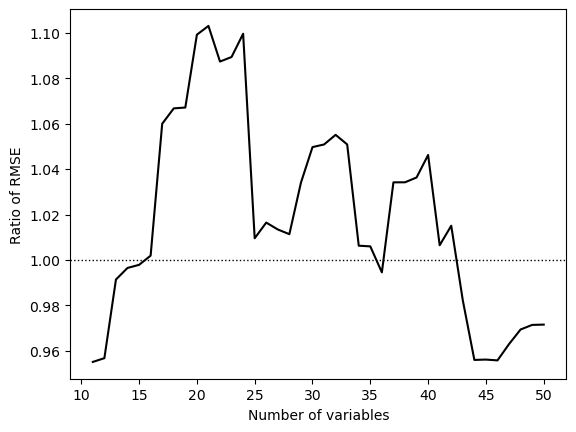

OLS benchmark RMSE : 2.3116
LARS min RMSE : 2.2078


In [21]:
# Best threshold is 1: where models outperform non-selected OLS
threshold = 1
d['ratio'].plot(color='black')                        # pandas .plot() wraps matplotlib for quick line charts
plt.axhline(y=threshold, color='black', linestyle=':', linewidth=1)  # draw a horizontal reference line at y=1
plt.ylabel("Ratio of RMSE")
plt.xlabel("Number of variables")
plt.legend().set_visible(False)
plt.show()   # plt.show() renders the figure; without it, the plot may not display outside notebooks

print(f"OLS benchmark RMSE : {benchmark:.4f}")
print(f"LARS min RMSE : {d['rmse'].min():.4f}")   # .min() returns the smallest value in the column

We will be interested in Nowcasting using specifications that include the variables selectected by LARS that outperform OLS.

However, for our example, we will use only one of those specifications.

Which one? The one with the best RMSE. We are going to create a list of specifications (spec_list) with all selected specifications. In our case, only one.

In [42]:
# Filter rows where rmse equals the minimum rmse â€” keeps only the best-performing specification
spec_list = d[d.index==d.index.max()]
spec_list

,selected_vars,rmse,ratio
size,,,
50,"[TREX1003, TREX1011, TDEX2002, TDEX2003, TDEX0...",2.245773,0.971531


## Basic Nowcasting

Nowcasting uses a variety of functions. These functions:

- Generate lagged data according to the information set
- Flatten the data into a wide format where additional columns represent periods of the quarter
- Fill missing values with the mean

In [43]:
# lags is a list of integers representing information-set vintages
# negative = data available that many months BEFORE the GDP reference quarter
# positive = data available that many months AFTER the GDP reference quarter
lags = list(range(-2, 3))   # range(-2, 3) gives -2, -1, 0, 1, 2; list() converts it to a list

# helper function, generate lagged datasets for testing on vintages
def gen_lagged_data(metadata, data, last_date, lag):
    # only go up to the last date
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    for col in lagged_data.columns[1:]:   # [1:] slices the column list, skipping the first column (date)
        pub_lag = metadata.loc[metadata.ticket == col, "months_lag"].values[0] # publication lag of this particular variable
        # go back as far as needed for the pub_lag of the variable, then + the lag (so -2 for 2 months back), also -1 because 0 lag means in month, last month data available, not current month in
        lagged_data.loc[(len(lagged_data) - pub_lag + lag ) :, col] = np.nan
        # set the last pub_lag+lag rows to NaN â€” those values haven't been published yet

    return lagged_data

# helper function, flatten a dataset for methods that don't do timeseries, extra columns for each lag
def flatten_data(data, target_variable, n_lags):
    # keep only rows where GDP is observed (non-NaN)
    flattened_data = data.loc[~pd.isna(data[target_variable]), :]
    orig_index = flattened_data.index   # save the original row positions
    for i in range(1, n_lags):   # loop i = 1, 2, ..., n_lags-1
        lagged_indices = orig_index - i          # shift index back by i rows
        lagged_indices = lagged_indices[lagged_indices >= 0]   # drop any negative indices
        tmp = data.loc[lagged_indices, :].copy()   # .copy() avoids modifying the original DataFrame
        tmp['date'] = tmp['date'] + pd.DateOffset(months=i)   # DateOffset shifts dates forward by i months
        tmp = tmp.drop([target_variable], axis=1)
        # rename columns to indicate they are lagged (e.g., "VAR_1" = value 1 period ago)
        tmp.columns = [j + "_" + str(i) if j != "date" else j for j in tmp.columns]
        flattened_data = flattened_data.merge(tmp, how="left", on="date")   # left join on date column

    return flattened_data


def lagged_target(data, total_lags, metadata=metadata, target_variable=target_variable) :
    if total_lags == 0 :
        return data   # early return: if no lags requested, hand back the data unchanged
    else :
        for l in range(1,total_lags+1) :
            data[f"{target_variable}_l{l}"] = data[target_variable]   # copy GDP column, will shift it
            pub_lag_q = max(1, metadata[metadata['ticket']==target_variable]['months_lag'].values[0] // 3)
            # // is integer (floor) division; converts monthly publication lag to quarterly
            data.loc[data.index[-pub_lag_q:], f"{target_variable}_l{l}"] = np.nan
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].ffill()   # forward-fill NaN
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].shift(l)  # shift down by l rows
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].fillna(data[f"{target_variable}_l{l}"].mean())
        return data
    
# helper function fill missings in a dataset with the mean from the training set
def mean_fill_dataset(training, test):
    mean_dict = {}   # empty dict; will map column name -> training mean
    for col in training.columns[1:]:
        mean_dict[col] = np.nanmean(training[col])   # np.nanmean ignores NaN when computing the mean
    filled = test.copy()
    for col in training.columns[1:]:
        # replace NaN in test with the training mean (avoids data leakage from test set)
        filled.loc[pd.isna(filled[col]), col] = mean_dict[col]
        
    return filled


def fit_ols(
    ttrain ,
    gdp_lags = 0,
    flat_lags = 3 ,
    target_variable = target_variable,
    ) :
    transformed_train = flatten_data(ttrain, target_variable, flat_lags )
    # keep only quarter-end months (March=3, June=6, Sep=9, Dec=12) â€” GDP is quarterly
    # .dt.month extracts the month number from a datetime column
    transformed_train = transformed_train.loc[transformed_train.date.dt.month.astype(int).isin([3,6,9,12]),:].fillna(transformed_train.mean(numeric_only=True)).dropna(axis=1).reset_index(drop=True)
    transformed_train = lagged_target(transformed_train, gdp_lags)
    
    model = LinearRegression()
    x = transformed_train.drop(["date", target_variable], axis=1)
    y = transformed_train[target_variable]
    return model.fit(x, y) , x.columns   # returns both the fitted model AND the column names used


def predict_ols(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l,
    flat_lags = 3 ,
    gdp_lags = 0 ,
    target_variable = target_variable,
    ) :
    # Apply model in test
    Xi = flatten_data(X, target_variable, flat_lags )
    Xi = lagged_target(Xi, gdp_lags)
        
    # Select only the single row matching the target date
    Xi = Xi.loc[Xi['date'] == date, :].drop(["date", target_variable], axis=1)
    Xi = Xi[train_vars]   # reorder/subset columns to match what the model was trained on
    
    pred = model.predict(Xi)[0]   # [0] extracts the scalar from the 1-element array returned by predict
    pred_dict[l].append(pred)     # append prediction to the list for this lag (l) in the dictionary
    return pred_dict


def perform_tab( pred_values , model_name , specification , values , lags=lags) :
    # table of RMSE by vintage
    table = pd.DataFrame(columns=[ "Vintage", "RMSE", "estimator", "spec" ])
    for lag in lags:
        tmp = pd.DataFrame({
            "Vintage" : lag,
            # np.array() converts lists to arrays so element-wise subtraction works correctly
            "RMSE" : np.sqrt(np.mean((np.array(values) - np.array(pred_values[lag])) ** 2)) ,
            "estimator": model_name ,
            "spec" : specification ,
        }, index=[0])   # index=[0] required when all values are scalars (not lists)
        table = pd.concat([table, tmp]).reset_index(drop=True)   # pd.concat stacks DataFrames vertically
    table.round(4)
    table.set_index('Vintage' , inplace=True)
    return table

def forecast_table( pred_values , model_name , specification, values  , dates ) :
    # plot of predictions vs actuals
    result = pd.DataFrame(
        {
            "observed": actuals ,
            "two_back": pred_values[-2] ,   # dictionary key -2: info set 2 months before GDP release
            "one_back": pred_values[-1] ,
            "zero_back": pred_values[0] ,   # key 0: contemporaneous information set
            "one_ahead": pred_values[1] ,
            "two_ahead": pred_values[2] ,
            "estimator": model_name ,
            "spec": specification ,
        }
    )
    result.index = pd.to_datetime(dates)   # assign proper date index to the result table
    return result


We are going to start the Nowcasting exercise with the original (cleaned) dataset in mixed frequencies (Not quarterly)

(The reason is that LARS cannot handle mixed frequencies and flattening. The nowcasting methodology can handle it).

However, limit the variable list to only those selected by LARS + GDP (the target variable)

In [44]:
# .values[0] extracts the first (and only) element from the numpy array stored in the cell
XVars = spec_list['selected_vars'].values[0]
print(XVars)         # print the list of selected variable names
print(len(XVars))    # len() returns the number of items in a list

['TREX1003', 'TREX1011', 'TDEX2002', 'TDEX2003', 'TDEX0009', 'TBBI1031', 'TREX1016', 'TREX1028', 'TBBI1002', 'TDEX2010', 'TDEX2005', 'TBBI1038', 'TREX1004', 'FLOA0011', 'TBBI1040', 'TBBI1001', 'TDEX1004', 'TREX1017', 'TREX1030', 'TDEX1001', 'TBBI1017', 'TDEX0010', 'TDEX0003', 'TBBI1018', 'TEXP1015', 'TDEX0015', 'TREX1036', 'TDEX0017', 'FLOA0004', 'TREX1012', 'TEXP1003', 'TEXP0001', 'TREX1034', 'TREX1029', 'TDEX1005', 'TDEX0002', 'TREX1010', 'TREX1009', 'TREX1023', 'TREX1026', 'TREX1005', 'TREX1007', 'TREX1032', 'TDEX2011', 'TREX1008', 'FLOA0026', 'TEXP0002', 'TREX1022', 'MASS0010', 'RTOU0000']
50


In [45]:
# Keep only LARS-selected predictors plus the GDP target; list comprehension filters data.columns
df = data[[ col for col in data.columns if col in XVars or col == target_variable ]]
print(f"Data shape: {df.shape}")   # .shape returns (number of rows, number of columns)
df.tail(2)

Data shape: (135, 51)


,RGDP0000,RTOU0000,TEXP1015,TEXP1003,TDEX0015,TDEX0017,TDEX0009,TDEX0010,TDEX0003,TDEX0002,...,TREX1007,TREX1008,TEXP0001,TEXP0002,TBBI1018,TBBI1038,FLOA0004,FLOA0011,FLOA0026,MASS0010
date,,,,,,,,,,,,,,,,,,,,,
2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Generate Test dataset**

The test dataset is tricky. It is not a real test dataset. Sorry. Unfortunate name choice.

The test dataset includes all the train data + test data. This was done due to PCA construction.

We will separate it into an actual training and test dataset later.

In [46]:
df = df.reset_index(drop=False)   # move the date index back to a plain column called 'date'
# .dropna(axis=1, thresh=23): drop any column that has fewer than 23 non-NaN values
df.dropna(axis=1, thresh=23, inplace=True)
# Filter rows within the full sample window (train + test)
test = df.loc[(df.date >= train_start_date) & (df.date <= test_end_date), :].reset_index(drop=True)
# DATES AND ACTUAL VALUES
# pd.date_range generates evenly spaced quarterly dates; freq="3MS" = every 3 month-starts
# .strftime("%Y-%m-%d") formats each Timestamp as a string; .tolist() converts to a plain Python list
dates = ( pd.date_range(test_start_date, test_end_date, freq="3MS").strftime("%Y-%m-%d").tolist() )
# .isin(dates) checks which rows in test fall on a test-period GDP date; .values extracts as array
actuals = list(test.loc[test.date.astype(str).isin(dates), target_variable].values)

The list 'dates' includes all (actual) test dates. For each date in the test, we are going to generate a nowcast. The nowcast depends on what month we are located because each month has a different information set.

What that means is that training models are rolling over time, benefitting from additional information that gets published.

In [47]:
dates

['2023-06-01',
 '2023-09-01',
 '2023-12-01',
 '2024-03-01',
 '2024-06-01',
 '2024-09-01',
 '2024-12-01',
 '2025-03-01',
 '2025-06-01',
 '2025-09-01',
 '2025-12-01']

## Estimation with one information set and one period

In [72]:
# param_pca is the number of factors included.
param_pca = 1
# " ".join(list) concatenates all items in XVars into a single space-separated string
spec = " ".join(XVars)

date = dates[0]   # take the first test date (dates is a list of strings)
date

'2023-06-01'

The training set rolls over time, depending of the test period we are nowcasting. Therefore, it is defined as a function of the test period.

In [73]:
# define train dataset
# pd.to_datetime(date) converts the string date to a Timestamp so we can do arithmetic
# DateOffset(months=3) shifts the date back by one quarter â€” training ends before the test quarter
train = test.loc[test.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10],:]
# str(...)[:10] slices the first 10 characters of the Timestamp string to get "YYYY-MM-DD"
train

,date,RGDP0000,RTOU0000,TEXP1015,TEXP1003,TDEX0015,TDEX0017,TDEX0009,TDEX0010,TDEX0003,...,TREX1007,TREX1008,TEXP0001,TEXP0002,TBBI1018,TBBI1038,FLOA0004,FLOA0011,FLOA0026,MASS0010
0,2015-03-01,-3.656570,-2.458681,173.328825,-41.994212,164.312348,-66.177851,-78.333129,-213.188057,-53.872530,...,-96.460462,-72.878250,-84.072492,64.648456,70.023746,NaN,-0.899596,4950.267675,47.060210,-53.498524
1,2015-04-01,NaN,31.446352,-72.887663,22.924894,-89.032143,-740.523099,281.901978,-198.369192,103.278747,...,2094.759362,-74.253131,104.400039,-34.239012,18.793024,NaN,-7.602557,-25.644347,-173.704087,117.351373
2,2015-05-01,NaN,-1.199341,79.854126,-15.945348,157.949136,-52.399493,-89.096961,9.607170,-51.721199,...,1.516182,-35.027448,207.330499,-40.619154,-58.676855,NaN,-0.399568,-72.450705,-45.105678,-125.561296
3,2015-06-01,4.238383,4.442582,4.436360,12.388383,-52.106592,-322.803265,-1878.244877,142.366922,40.397317,...,84.966222,-272.648268,-79.110556,-84.699758,19.242573,NaN,-1.090157,44.671994,-13.399385,-58.690316
4,2015-07-01,NaN,0.531231,-20.088731,-59.685780,213.696356,-22.161750,-107.730997,-75.203324,-81.930960,...,-75.696631,-1316.626386,395.151704,1943.231468,251.183577,NaN,5.915520,-132.708197,121.051409,439.947600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,2022-11-01,NaN,-21.920642,-43.803916,-61.259004,-128.589770,-3.127313,164.470831,-88.580856,-54.726055,...,10.265604,-51.587539,-11.436817,-61.171012,-84.131963,-11.871495,-32.057937,-1.018699,5.029502,-225.672157
93,2022-12-01,-1.842823,25.539539,-86.983838,-21.423997,-562.489322,-302.917647,116.833948,670.480250,-16.828269,...,-173.262975,85.129790,-34.290535,-19.484559,-88.066936,-92.487305,-20.370409,-29.779290,-9.739721,-571.189769
94,2023-01-01,NaN,38.115411,-184.522834,-53.108366,35.124464,-67.621189,-77.946120,58.342397,-22.606684,...,-219.017835,-49.785364,-29.189323,19.402256,-879.366554,-130.254533,726.362541,-6.924504,14.689308,-91.179483
95,2023-02-01,NaN,15.431396,-1913.145731,85.449681,-17.472404,-221.970744,190.477966,259.505716,19.473266,...,26.717882,-489.182727,102.450186,-21.648972,-1010.860975,-3453.038829,-5.545007,-7.470369,-18.473782,-941.779148


We populate missing values

In [74]:
transformed_train = mean_fill_dataset(train, train)
transformed_train

,date,RGDP0000,RTOU0000,TEXP1015,TEXP1003,TDEX0015,TDEX0017,TDEX0009,TDEX0010,TDEX0003,...,TREX1007,TREX1008,TEXP0001,TEXP0002,TBBI1018,TBBI1038,FLOA0004,FLOA0011,FLOA0026,MASS0010
0,2015-03-01,-3.656570,-2.458681,173.328825,-41.994212,164.312348,-66.177851,-78.333129,-213.188057,-53.872530,...,-96.460462,-72.878250,-84.072492,64.648456,70.023746,-40.683812,-0.899596,4950.267675,47.060210,-53.498524
1,2015-04-01,0.420691,31.446352,-72.887663,22.924894,-89.032143,-740.523099,281.901978,-198.369192,103.278747,...,2094.759362,-74.253131,104.400039,-34.239012,18.793024,-40.683812,-7.602557,-25.644347,-173.704087,117.351373
2,2015-05-01,0.420691,-1.199341,79.854126,-15.945348,157.949136,-52.399493,-89.096961,9.607170,-51.721199,...,1.516182,-35.027448,207.330499,-40.619154,-58.676855,-40.683812,-0.399568,-72.450705,-45.105678,-125.561296
3,2015-06-01,4.238383,4.442582,4.436360,12.388383,-52.106592,-322.803265,-1878.244877,142.366922,40.397317,...,84.966222,-272.648268,-79.110556,-84.699758,19.242573,-40.683812,-1.090157,44.671994,-13.399385,-58.690316
4,2015-07-01,0.420691,0.531231,-20.088731,-59.685780,213.696356,-22.161750,-107.730997,-75.203324,-81.930960,...,-75.696631,-1316.626386,395.151704,1943.231468,251.183577,-40.683812,5.915520,-132.708197,121.051409,439.947600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,2022-11-01,0.420691,-21.920642,-43.803916,-61.259004,-128.589770,-3.127313,164.470831,-88.580856,-54.726055,...,10.265604,-51.587539,-11.436817,-61.171012,-84.131963,-11.871495,-32.057937,-1.018699,5.029502,-225.672157
93,2022-12-01,-1.842823,25.539539,-86.983838,-21.423997,-562.489322,-302.917647,116.833948,670.480250,-16.828269,...,-173.262975,85.129790,-34.290535,-19.484559,-88.066936,-92.487305,-20.370409,-29.779290,-9.739721,-571.189769
94,2023-01-01,0.420691,38.115411,-184.522834,-53.108366,35.124464,-67.621189,-77.946120,58.342397,-22.606684,...,-219.017835,-49.785364,-29.189323,19.402256,-879.366554,-130.254533,726.362541,-6.924504,14.689308,-91.179483
95,2023-02-01,0.420691,15.431396,-1913.145731,85.449681,-17.472404,-221.970744,190.477966,259.505716,19.473266,...,26.717882,-489.182727,102.450186,-21.648972,-1010.860975,-3453.038829,-5.545007,-7.470369,-18.473782,-941.779148


Reduce dimensions with a PCA.

In [75]:
# Standardize predictors: .set_index('date').drop(target_variable) removes date & GDP columns
# scaler.fit_transform() returns a numpy array; wrap in pd.DataFrame() to restore column names
X = pd.DataFrame(scaler.fit_transform(transformed_train.set_index('date').drop(target_variable, axis=1)))
X.columns = transformed_train.set_index('date').drop(target_variable, axis=1).columns   # restore column names
X = X.dropna(axis=1)   # drop any all-NaN columns after scaling
pca = PCA(n_components=param_pca)   # create a new PCA object with the chosen number of components

X = pca.fit_transform(X)   # learn components from this training slice and project X onto them
X = pd.DataFrame(X)
# .rename(columns=lambda x: ...) applies a function to every column name; lambda is an anonymous function
X.rename(columns=lambda x: f'PC_{x}', inplace=True)
# pd.concat with axis=1 joins DataFrames side-by-side (column-wise)
transformed_train = pd.concat( [ transformed_train[['date', target_variable]] , X ] ,axis=1)
transformed_train

,date,RGDP0000,PC_0
0,2015-03-01,-3.656570,0.486829
1,2015-04-01,0.420691,1.329125
2,2015-05-01,0.420691,-0.235122
3,2015-06-01,4.238383,-0.098166
4,2015-07-01,0.420691,0.441026
...,...,...,...
92,2022-11-01,0.420691,0.083707
93,2022-12-01,-1.842823,-1.154665
94,2023-01-01,0.420691,0.830393
95,2023-02-01,0.420691,-0.576729


The data has mixed frequencies: GDP is quarterly (although we observe the mean instead of missing values) but the other variables are monthly.

Data flattening adds the months of a quarter as additioanl columns.

In [76]:
flats = 3   # number of within-quarter months to include as extra columns (months 1, 2, 3 of each quarter)
# flatten_data adds lagged columns so each quarterly row carries all monthly info for that quarter
transformed_train = flatten_data(transformed_train, target_variable, flats )
transformed_train

,date,RGDP0000,PC_0,PC_0_1,PC_0_2
0,2015-03-01,-3.656570,0.486829,NaN,NaN
1,2015-04-01,0.420691,1.329125,0.486829,NaN
2,2015-05-01,0.420691,-0.235122,1.329125,0.486829
3,2015-06-01,4.238383,-0.098166,-0.235122,1.329125
4,2015-07-01,0.420691,0.441026,-0.098166,-0.235122
...,...,...,...,...,...
92,2022-11-01,0.420691,0.083707,0.375710,5.228446
93,2022-12-01,-1.842823,-1.154665,0.083707,0.375710
94,2023-01-01,0.420691,0.830393,-1.154665,0.083707
95,2023-02-01,0.420691,-0.576729,0.830393,-1.154665


Now keep only quarters.

In [77]:
# .dt.month extracts month as integer from a datetime column
# .isin([3,6,9,12]) keeps only rows where month is a quarter-end (Mar, Jun, Sep, Dec)
# .fillna(mean) fills any remaining NaN with column means; .dropna(axis=1) drops all-NaN columns
transformed_train = transformed_train.loc[transformed_train.date.dt.month.astype(int).isin([3,6,9,12]),:].fillna(transformed_train.mean()).dropna(axis=1).reset_index(drop=True)
transformed_train.tail(5)

,date,RGDP0000,PC_0,PC_0_1,PC_0_2
28,2022-03-01,3.565568,-0.465229,-0.206277,-0.216080
29,2022-06-01,-0.850986,-0.125047,0.425625,0.910747
30,2022-09-01,-0.717400,5.228446,0.292317,-4.157669
31,2022-12-01,-1.842823,-1.154665,0.083707,0.375710
32,2023-03-01,5.347331,-0.292709,-0.576729,0.830393


In some instances we may want to add autorregressive terms to the model. (Missings are filled with the mean)

In [78]:
gdp_lags = 2   # include 2 autoregressive lags of GDP as additional predictors
# lagged_target() appends columns like RGDP0000_l1, RGDP0000_l2 to the DataFrame
transformed_train = lagged_target(transformed_train, gdp_lags)
transformed_train

,date,RGDP0000,PC_0,PC_0_1,PC_0_2,RGDP0000_l1,RGDP0000_l2
0,2015-03-01,-3.656570,0.486829,0.003049,0.009152,0.266734,0.334784
1,2015-06-01,4.238383,-0.098166,-0.235122,1.329125,-3.656570,0.334784
2,2015-09-01,-0.482324,2.275812,0.537251,0.441026,4.238383,-3.656570
3,2015-12-01,1.569703,-0.354523,-0.478179,9.361984,-0.482324,4.238383
4,2016-03-01,-1.974436,0.501174,-0.312110,-0.233867,1.569703,-0.482324
5,2016-06-01,1.864651,1.043733,-1.080594,0.180908,-1.974436,1.569703
6,2016-09-01,-0.392329,0.811201,0.015909,-0.055347,1.864651,-1.974436
7,2016-12-01,0.975630,-0.252474,-0.851312,-0.823101,-0.392329,1.864651
8,2017-03-01,0.226985,0.864120,-0.270515,-0.718478,0.975630,-0.392329
9,2017-06-01,-0.132897,0.270513,-0.540394,0.064784,0.226985,0.975630


Estimate the model

In [79]:
model = LinearRegression()   # create a fresh OLS model object
# Build X (predictors) by dropping the date and GDP target columns
x = transformed_train.drop(["date", target_variable], axis=1)
y = transformed_train[target_variable]
model.fit(x, y)   # estimate OLS coefficients; the fitted model is returned (and stored in 'model')

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


With the trained model, it is time to work on the test sample.

The test sample includes observations that are unavailable due to publication lags. These publication lags are defined in the metadata.

We artificially set up the test data to include missings according to the publication lag.

In [81]:
date

'2023-06-01'

In [82]:
lag = -2   # -2 means 2 months before the GDP reference quarter (early vintage, less data available)
# gen_lagged_data() artificially sets future observations to NaN to simulate publication lags
tmp_data = gen_lagged_data(metadata, test, date, lag)
tmp_data

,date,RGDP0000,RTOU0000,TEXP1015,TEXP1003,TDEX0015,TDEX0017,TDEX0009,TDEX0010,TDEX0003,...,TREX1007,TREX1008,TEXP0001,TEXP0002,TBBI1018,TBBI1038,FLOA0004,FLOA0011,FLOA0026,MASS0010
0,2015-03-01,-3.656570,-2.458681,173.328825,-41.994212,164.312348,-66.177851,-78.333129,-213.188057,-53.872530,...,-96.460462,-72.878250,-84.072492,64.648456,70.023746,NaN,-0.899596,4950.267675,47.060210,-53.498524
1,2015-04-01,NaN,31.446352,-72.887663,22.924894,-89.032143,-740.523099,281.901978,-198.369192,103.278747,...,2094.759362,-74.253131,104.400039,-34.239012,18.793024,NaN,-7.602557,-25.644347,-173.704087,117.351373
2,2015-05-01,NaN,-1.199341,79.854126,-15.945348,157.949136,-52.399493,-89.096961,9.607170,-51.721199,...,1.516182,-35.027448,207.330499,-40.619154,-58.676855,NaN,-0.399568,-72.450705,-45.105678,-125.561296
3,2015-06-01,4.238383,4.442582,4.436360,12.388383,-52.106592,-322.803265,-1878.244877,142.366922,40.397317,...,84.966222,-272.648268,-79.110556,-84.699758,19.242573,NaN,-1.090157,44.671994,-13.399385,-58.690316
4,2015-07-01,NaN,0.531231,-20.088731,-59.685780,213.696356,-22.161750,-107.730997,-75.203324,-81.930960,...,-75.696631,-1316.626386,395.151704,1943.231468,251.183577,NaN,5.915520,-132.708197,121.051409,439.947600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2023-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,102.450186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,2023-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,2023-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,2023-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Publication Lags Example:
# Select an example column
tmp_data.columns

Index(['date', 'RGDP0000', 'RTOU0000', 'TEXP1015', 'TEXP1003', 'TDEX0015',
       'TDEX0017', 'TDEX0009', 'TDEX0010', 'TDEX0003', 'TDEX0002', 'TDEX2011',
       'TDEX2005', 'TDEX2003', 'TDEX2002', 'TDEX2010', 'TDEX1005', 'TDEX1001',
       'TDEX1004', 'TBBI1040', 'TBBI1017', 'TBBI1031', 'TBBI1001', 'TBBI1002',
       'TREX1004', 'TREX1029', 'TREX1028', 'TREX1036', 'TREX1017', 'TREX1034',
       'TREX1030', 'TREX1032', 'TREX1003', 'TREX1009', 'TREX1010', 'TREX1012',
       'TREX1011', 'TREX1016', 'TREX1022', 'TREX1026', 'TREX1023', 'TREX1005',
       'TREX1007', 'TREX1008', 'TEXP0001', 'TEXP0002', 'TBBI1018', 'TBBI1038',
       'FLOA0004', 'FLOA0011', 'FLOA0026', 'MASS0010'],
      dtype='object')

In [ ]:
# to see how gen_lagged_data() blanked out the most recent observations
ex_col = 'TEXP0001'
tmp_data[['date', ex_col]].tail(10)

,date,TEXP0001
90,2022-09-01,-57.488156
91,2022-10-01,260.506053
92,2022-11-01,-11.436817
93,2022-12-01,-34.290535
94,2023-01-01,-29.189323
95,2023-02-01,102.450186
96,2023-03-01,NaN
97,2023-04-01,NaN
98,2023-05-01,NaN
99,2023-06-01,NaN


Remember we are currently in month:

In [90]:
date, lag

('2023-06-01', -2)

In [ ]:
metadata[metadata['ticket'] == ex_col]

,series,ticket,description,description 2,freq,first_date,last_date,No Obs,months_lag,nominal,sa,unstructured,type,agg_method,file_name,first_obs,last_obs
76,exports_can,TEXP0001,exports_can,NaN,monthly,1996-01-01,2026-03-01,195,2,0,0,0,NaN,sum,canada_exports.csv,1996-01-01,2026-03-01


Fill missing values with the mean and estimate the factors

In [91]:
# Fill NaN in test data using means computed from the training data (avoids leakage)
tmp_data = mean_fill_dataset(train, tmp_data)
# The 'or' condition is always True here (both branches do the same thing); PCA is always applied
if param_pca != False or param_pca != 0 :
    X = pd.DataFrame(scaler.fit_transform(tmp_data.set_index('date').drop(target_variable, axis=1)))
    X.columns = tmp_data.set_index('date').drop(target_variable, axis=1).columns
    X = X.dropna(axis=1)
    pca = PCA(n_components=param_pca)
    
    X = pca.fit_transform(X)   # project test predictors onto principal components
    X = pd.DataFrame(X)
    X.rename(columns=lambda x: f'PC_{x}', inplace=True)
    
    # Reassemble: date + GDP (target) columns on the left, PCA factors on the right
    tmp_data = pd.concat( [ tmp_data[['date', target_variable]] , X ] ,axis=1)
tmp_data

,date,RGDP0000,PC_0
0,2015-03-01,-3.656570,0.447482
1,2015-04-01,0.420691,1.317905
2,2015-05-01,0.420691,-0.255936
3,2015-06-01,4.238383,-0.139889
4,2015-07-01,0.420691,0.362028
...,...,...,...
95,2023-02-01,0.420691,-0.007623
96,2023-03-01,0.420691,-0.006845
97,2023-04-01,0.420691,-0.006845
98,2023-05-01,0.420691,-0.006845


To predict in the test set using coefficients from the training model, we need to emulate the same columns as in the training sample.
Therefore, follow the same procedure as before.

In [92]:
# Apply the same flattening and lagging transformations as were done during training
tmp_data = flatten_data(tmp_data, target_variable, flats )
tmp_data = lagged_target(tmp_data, gdp_lags )
# Keep only the single row for the target date; drop date and GDP (not needed for prediction)
tmp_data = tmp_data.loc[tmp_data['date']== date, :].drop(["date", target_variable], axis=1)
tmp_data

,PC_0,PC_0_1,PC_0_2,RGDP0000_l1,RGDP0000_l2
99,-0.006845,-0.006845,-0.006845,0.420691,0.420691


Now get the predicted value for a test date, under an information set lag.

In [93]:
# model.predict() returns an array; [0] pulls out the scalar nowcast value
pred = model.predict(tmp_data)[0]
# Displaying a tuple prints all three values side by side in the notebook output
date, lag, pred

('2023-06-01', -2, np.float64(0.4179663503990113))

## Estimation and Prediction Loop

The estimation will use 3 PCA factors of selected variables.

The model will be trained depending on the data available at each date.

```transformed_train``` is a dataset that includes the selected variables as factors without missing values.

In [94]:
# param_pca is the number of factors included.
param_pca = 1
# " ".join(list) builds a single string from list items â€” used as a readable label for this spec
spec = " ".join(XVars)

# Dictionary comprehension: create {lag: []} for each lag in lags
# This will store predicted GDP values for each information-set vintage
pred_ols = { k: [] for k in lags }
# Empty DataFrames that will be filled by concatenating results in the loop
performance_table = pd.DataFrame()
result_table = pd.DataFrame()

for date in dates :    # outer loop: iterate over each quarterly test period

    # Rolling training set: everything before the current test quarter
    train = test.loc[test.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10],:]
    transformed_train = mean_fill_dataset(train, train)   # fill NaN with training means
    
    # -----------------------------------------------------------------
    # Run PCA scaling
    if param_pca != False or param_pca != 0 :
        if param_pca == True: param_pca=1

        X = pd.DataFrame(scaler.fit_transform(transformed_train.set_index('date').drop(target_variable, axis=1)))
        X.columns = transformed_train.set_index('date').drop(target_variable, axis=1).columns
        X = X.dropna(axis=1)
        pca = PCA(n_components=param_pca)
        
        X = pca.fit_transform(X)   # fit PCA on this rolling training window
        X = pd.DataFrame(X)
        X.rename(columns=lambda x: f'PC_{x}', inplace=True)
        transformed_train = pd.concat( [ transformed_train[['date', target_variable]] , X ] ,axis=1)

        
        ols_fit, ols_vars = fit_ols(   # fit_ols returns the model object and the column list
            transformed_train , 
            gdp_lags = gdp_lags,
            flat_lags = flats
        )

         # -----------------------------------------------------------------
        # Publication Lags in Test data
        for lag in lags:   # inner loop: iterate over each vintage (information set)
            # the data available for this date at this artificial vintage
            tmp_data = gen_lagged_data(metadata, test, date, lag)
            # get data in format necessary for model
            tmp_data = mean_fill_dataset(train, tmp_data)
            
            if param_pca != False or param_pca != 0 :
                X = pd.DataFrame(scaler.fit_transform(tmp_data.set_index('date').drop(target_variable, axis=1)))
                X.columns = tmp_data.set_index('date').drop(target_variable, axis=1).columns
                X = X.dropna(axis=1)
                pca = PCA(n_components=param_pca)
                
                X = pca.fit_transform(X)
                X = pd.DataFrame(X)
                X.rename(columns=lambda x: f'PC_{x}', inplace=True)
                
                tmp_data = pd.concat( [ tmp_data[['date', target_variable]] , X ] ,axis=1)

            # -----------------------------------------------------------------
            # Predicted values: append nowcast for this (date, lag) to pred_ols
            pred_ols = predict_ols(
                model=ols_fit,
                X = tmp_data ,
                train_vars = ols_vars,
                date = date,
                l = lag,
                pred_dict = pred_ols ,   # pred_dict is updated in-place and returned
                flat_lags = flats ,
                gdp_lags = gdp_lags,
                )
            
# pd.concat stacks the per-specification tables vertically into one summary table
performance_table = pd.concat( [ performance_table , perform_tab(pred_ols, "OLS", spec , actuals) ], axis=0)
result_table = pd.concat( [ result_table , forecast_table(pred_ols, "OLS", spec , actuals, dates) ], axis=0)

We observe the results of Nowcasting with OLS in different information windows.

In [95]:
result_table

,observed,two_back,one_back,zero_back,one_ahead,two_ahead,estimator,spec
2023-06-01,-1.407125,0.417966,0.437187,0.421118,0.430645,0.396736,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2023-09-01,-1.910147,0.461728,0.467439,0.457745,0.456299,0.363561,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2023-12-01,1.089106,0.445943,0.442146,0.423205,0.425295,0.328987,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2024-03-01,4.256604,1.177506,1.146221,1.138738,1.152140,1.371659,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2024-06-01,-0.776445,1.150113,1.173668,1.187762,1.170680,1.144118,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2024-09-01,-0.908100,0.658835,0.664278,0.657118,0.613755,0.599138,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2024-12-01,3.426665,0.578592,0.587139,0.582739,0.579048,0.577749,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2025-03-01,1.033989,0.627636,0.613242,0.612603,0.602771,0.513665,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2025-06-01,-1.366655,0.619965,0.621841,0.623087,0.627367,0.448520,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2025-09-01,-0.343411,0.790345,0.791663,0.784244,0.748738,0.860103,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...


In [96]:
performance_table

,RMSE,estimator,spec
Vintage,,,
-2,2.098421,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
-1,2.115917,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
0,2.116652,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
1,2.111629,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...
2,2.066891,OLS,TREX1003 TREX1011 TDEX2002 TDEX2003 TDEX0009 T...


<Axes: >

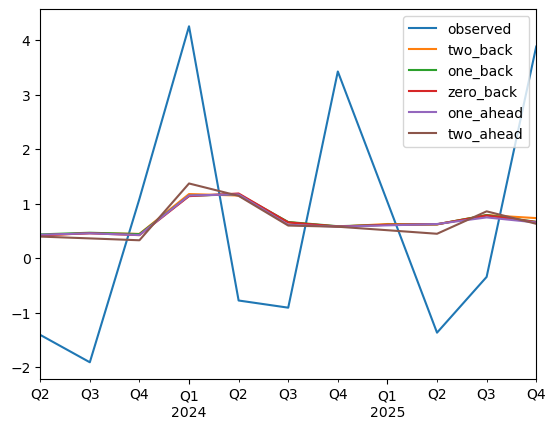

In [97]:
result_table.plot()